<a href="https://colab.research.google.com/github/OlhaHarkusha/Lab1_GroupProject/blob/main/%D0%9B%D0%A04_3_10_%D0%93%D0%B0%D1%80%D0%BA%D1%83%D1%88%D0%B0_ipynb%22.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Лабораторна робота 3. Машинне навчання
## Регресія: прогнозування вартості нерухомості

**Мета роботи:** виконати первинний аналіз даних, побудувати кілька моделей регресії, оцінити їхню якість та виконати підбір гіперпараметрів для моделі Random Forest.

### Датасет
Можна використати один із двох способів завантаження даних:

1. Завантажити файл з Google Drive:
https://drive.google.com/file/d/1u_-3X05st6uvrgQB1qNLyE8a7QjTJjvd/view?usp=sharing

2. Завантажити датасет з Kaggle:
https://www.kaggle.com/datasets/prokshitha/home-value-insights

> Посилання та вміст датасету на зовнішніх платформах можуть змінюватися.

## 1. Імпорт бібліотек
Імпортуйте бібліотеки, необхідні для роботи з даними, візуалізації та числових обчислень.

In [1]:
# Ваш код:
# Імпортуйте pandas, numpy, matplotlib.pyplot, seaborn та інші потрібні бібліотеки.
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import kagglehub
import os
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, PowerTransformer, StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error,
)

## 2. Завантаження даних
Завантажте файл двома способами.

### Варіант 1. Завантаження файлу з комп’ютера
Завантажте CSV-файл у середовище Colab.

In [2]:
# Ваш код:
# Завантажте файл і збережіть дані у DataFrame `df`.
path = kagglehub.dataset_download("hellbuoy/car-price-prediction")
print("Path to dataset files:", path)

Using Colab cache for faster access to the 'car-price-prediction' dataset.
Path to dataset files: /kaggle/input/car-price-prediction


### Варіант 2. Завантаження датасету з Kaggle
Завантажте датасет безпосередньо з Kaggle та прочитайте CSV-файл у DataFrame `df`.

In [3]:
# Ваш код:
# Завантажте датасет з Kaggle та створіть DataFrame `df`.
path = kagglehub.dataset_download("hellbuoy/car-price-prediction")
df =  pd.read_csv(os.path.join(path, "CarPrice_Assignment.csv"))

display(df.head())

Using Colab cache for faster access to the 'car-price-prediction' dataset.


,car_ID,symboling,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,...,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
0,1,3,alfa-romero giulia,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0
1,2,3,alfa-romero stelvio,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0
2,3,1,alfa-romero Quadrifoglio,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0
3,4,2,audi 100 ls,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.0
4,5,2,audi 100ls,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.0


## 3. Опис ознак датасету

- **Square_Footage** — загальна житлова площа будинку.
- **Num_Bedrooms** — кількість спалень.
- **Num_Bathrooms** — кількість ванних кімнат.
- **Year_Built** — рік побудови будинку.
- **Lot_Size** — розмір земельної ділянки.
- **Garage_Size** — розмір гаража або кількість паркомісць.
- **Neighborhood_Quality** — оцінка якості району.
- **House_Price** — ціна будинку, цільова змінна.

## 4. Первинний аналіз даних

### Завдання 1. Перегляд даних
Виведіть перші рядки датасету та перегляньте його структуру.

In [4]:
# Ваш код:
# Виведіть кілька перших рядків та загальну інформацію про DataFrame.
print("Розмір датасету:", df.shape)
df.info

Розмір датасету: (205, 26)


<bound method DataFrame.info of      car_ID  symboling                   CarName fueltype aspiration  \
0         1          3        alfa-romero giulia      gas        std   
1         2          3       alfa-romero stelvio      gas        std   
2         3          1  alfa-romero Quadrifoglio      gas        std   
3         4          2               audi 100 ls      gas        std   
4         5          2                audi 100ls      gas        std   
..      ...        ...                       ...      ...        ...   
200     201         -1           volvo 145e (sw)      gas        std   
201     202         -1               volvo 144ea      gas      turbo   
202     203         -1               volvo 244dl      gas        std   
203     204         -1                 volvo 246   diesel      turbo   
204     205         -1               volvo 264gl      gas      turbo   

    doornumber      carbody drivewheel enginelocation  wheelbase  ...  \
0          two  convertible        rwd          front       88.6  ...   
1          two  convertible        rwd          front       88.6  ...   
2          two    hatchback        rwd          front       94.5  ...   
3         four        sedan        fwd          front       99.8  ...   
4         four        sedan        4wd          front       99.4  ...   
..         ...          ...        ...            ...        ...  ...   
200       four        sedan        rwd          front      109.1  ...   
201       four        sedan        rwd          front      109.1  ...   
202       four        sedan        rwd          front      109.1  ...   
203       four        sedan        rwd          front      109.1  ...   
204       four        sedan        rwd          front      109.1  ...   

     enginesize  fuelsystem  boreratio  stroke compressionratio horsepower  \
0           130        mpfi       3.47    2.68              9.0        111   
1           130        mpfi       3.47    2.68              9.0        111   
2           152        mpfi       2.68    3.47              9.0        154   
3           109        mpfi       3.19    3.40             10.0        102   
4           136        mpfi       3.19    3.40              8.0        115   
..          ...         ...        ...     ...              ...        ...   
200         141        mpfi       3.78    3.15              9.5        114   
201         141        mpfi       3.78    3.15              8.7        160   
202         173        mpfi       3.58    2.87              8.8        134   
203         145         idi       3.01    3.40             23.0        106   
204         141        mpfi       3.78    3.15              9.5        114   

     peakrpm citympg  highwaympg    price  
0       5000      21          27  13495.0  
1       5000      21          27  16500.0  
2       5000      19          26  16500.0  
3       5500      24          30  13950.0  
4       5500      18          22  17450.0  
..       ...     ...         ...      ...  
200     5400      23          28  16845.0  
201     5300      19          25  19045.0  
202     5500      18          23  21485.0  
203     4800      26          27  22470.0  
204     5400      19          25  22625.0  

[205 rows x 26 columns]>

In [5]:
df.head()

,car_ID,symboling,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,...,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
0,1,3,alfa-romero giulia,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0
1,2,3,alfa-romero stelvio,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0
2,3,1,alfa-romero Quadrifoglio,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0
3,4,2,audi 100 ls,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.0
4,5,2,audi 100ls,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.0


### Завдання 2. Перевірка дублікатів
Визначте кількість дубльованих рядків.

In [6]:
# Ваш код:
print ("Кількість пропущених значень:")
display(df.isna().sum().sort_values(ascending=False))

print("Повні дублікати:", df.duplicated().sum())
print(
    "Дублікати без урахування car_ID:",
    df.drop(columns="car_ID").duplicated().sum()
)

Кількість пропущених значень:


,0
car_ID,0
symboling,0
CarName,0
fueltype,0
aspiration,0
doornumber,0
carbody,0
drivewheel,0
enginelocation,0
wheelbase,0


Повні дублікати: 0
Дублікати без урахування car_ID: 0


### Завдання 3. Підготовка ідентифікатора та ознак

In [7]:
# Ваш код:
df['CarName'].value_counts()

,count
CarName,
peugeot 504,6
toyota corolla,6
toyota corona,6
subaru dl,4
mitsubishi outlander,3
...,...
volkswagen super beetle,1
volkswagen rabbit custom,1
volvo 245,1


In [8]:
ids = df["car_ID"].copy()
df_model = df.copy()
df_model["brand"] = (
    df_model["CarName"]
    .str.lower()
    .str.split()
    .str[0]
    .replace({
        "maxda": "mazda",
        "porcshce": "porsche",
        "toyouta": "toyota",
        "vokswagen": "volkswagen",
        "vw": "volkswagen",
    })
)
df_model = df_model.drop(columns=["car_ID", "CarName"])

In [9]:
df_model

,symboling,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,carlength,carwidth,...,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price,brand
0,3,gas,std,two,convertible,rwd,front,88.6,168.8,64.1,...,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0,alfa-romero
1,3,gas,std,two,convertible,rwd,front,88.6,168.8,64.1,...,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0,alfa-romero
2,1,gas,std,two,hatchback,rwd,front,94.5,171.2,65.5,...,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0,alfa-romero
3,2,gas,std,four,sedan,fwd,front,99.8,176.6,66.2,...,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.0,audi
4,2,gas,std,four,sedan,4wd,front,99.4,176.6,66.4,...,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.0,audi
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
200,-1,gas,std,four,sedan,rwd,front,109.1,188.8,68.9,...,mpfi,3.78,3.15,9.5,114,5400,23,28,16845.0,volvo
201,-1,gas,turbo,four,sedan,rwd,front,109.1,188.8,68.8,...,mpfi,3.78,3.15,8.7,160,5300,19,25,19045.0,volvo
202,-1,gas,std,four,sedan,rwd,front,109.1,188.8,68.9,...,mpfi,3.58,2.87,8.8,134,5500,18,23,21485.0,volvo
203,-1,diesel,turbo,four,sedan,rwd,front,109.1,188.8,68.9,...,idi,3.01,3.40,23.0,106,4800,26,27,22470.0,volvo


### Завдання 4. Асиметрія початкових числових ознак

,skewness
compressionratio,2.610862
enginesize,1.947655
price,1.777678
horsepower,1.405310
wheelbase,1.050214
carwidth,0.904003
stroke,-0.689705
curbweight,0.681398
citympg,0.663704
highwaympg,0.539997


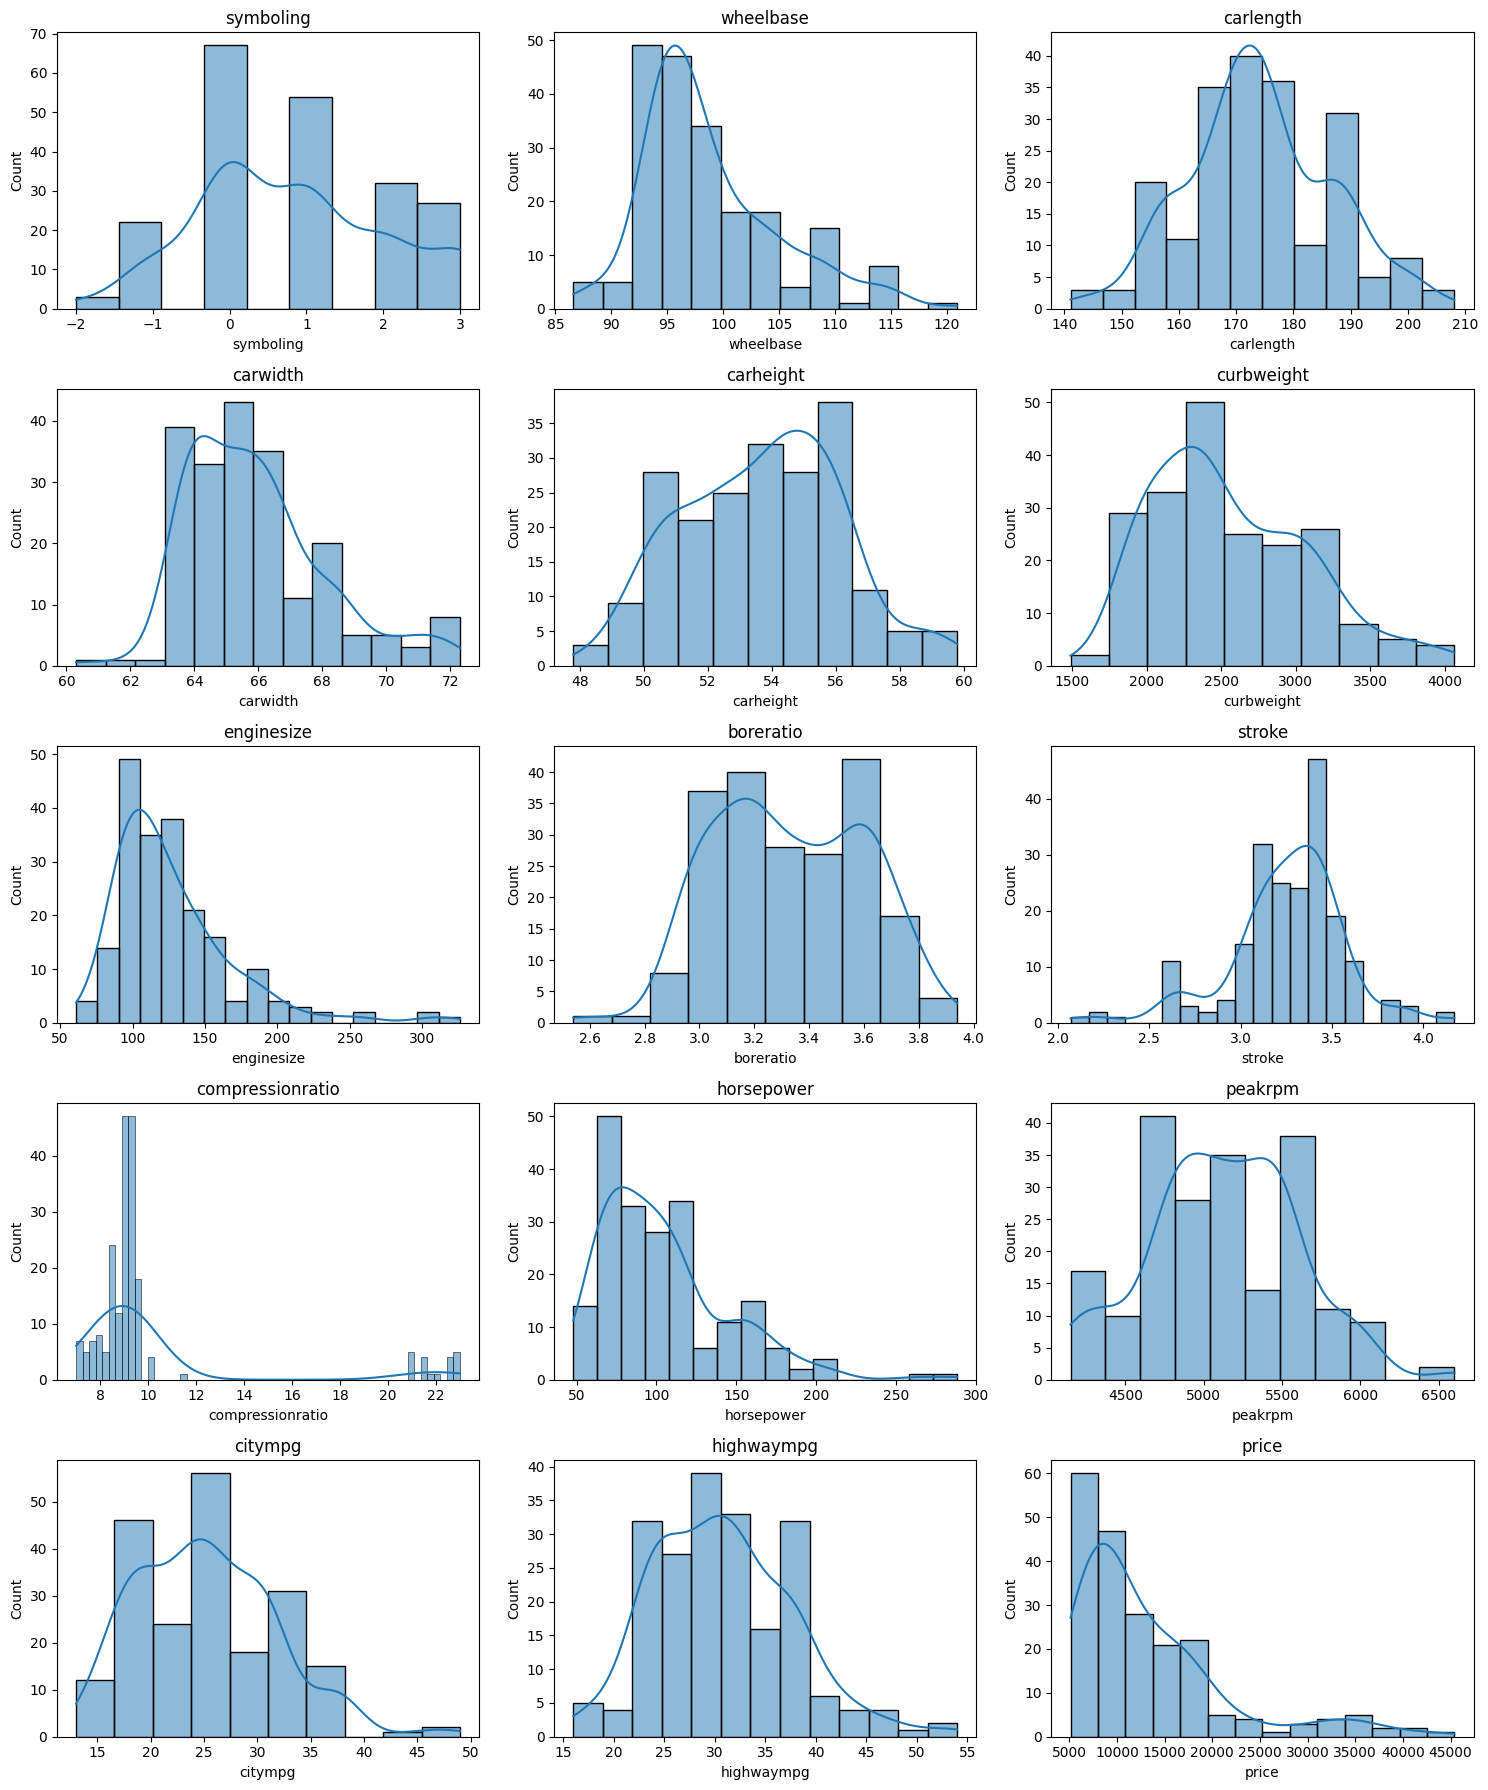

In [10]:
# Ваш код:
numeric_initial = df_model.select_dtypes(include=np.number).columns

skew_initial = df_model[numeric_initial].skew().sort_values(key=np.abs, ascending=False)

display(skew_initial.to_frame("skewness"))

n_cols = 3
n_rows = int(np.ceil(len(numeric_initial) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 3.6 * n_rows))
axes = np.array(axes).reshape(-1)
for ax, col in zip(axes, numeric_initial):
  sns.histplot(df_model[col], kde=True, ax=ax)
  ax.set_title(col)
for ax in axes[len(numeric_initial):]:
  ax.axis("off")
plt.tight_layout()
plt.show()

## 5. Поділ на тренувальну і тестову вибірки

In [11]:
# Ваш код:
X = df_model.drop(columns="price")

y = df_model["price"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
)

id_train = ids.loc[X_train.index]
id_test = ids.loc[X_test.index]

print("Train:", X_train.shape, "Test:", X_test.shape)

Train: (164, 24) Test: (41, 24)


### Завдання 6. Дослідження та обробка викидів

In [12]:
# Ваш код:
continuous_cols = [
    c for c in X_train.select_dtypes(include=np.number).columns
    if c != "symboling"
]
q1 = X_train[continuous_cols].quantile(0.25)

q3 = X_train[continuous_cols].quantile(0.75)

iqr = q3 - q1

lower_bounds = q1 - 1.5 * iqr

upper_bounds = q3 + 1.5 * iqr

outlier_counts = (
    (X_train[continuous_cols].lt(lower_bounds)) |
    (X_train[continuous_cols].gt(upper_bounds))
).sum().sort_values(ascending=False)

display(outlier_counts.to_frame("potential_outliers_train"))

X_train = X_train.copy()
X_test = X_test.copy()

X_train[continuous_cols] = X_train[continuous_cols].clip(
    lower=lower_bounds,
    upper=upper_bounds,
    axis=1
)

X_test[continuous_cols] = X_test[continuous_cols].clip(
    lower=lower_bounds,
    upper=upper_bounds,
    axis=1
)

,potential_outliers_train
compressionratio,20
stroke,16
carwidth,10
horsepower,7
enginesize,7
wheelbase,6
peakrpm,2
highwaympg,1
boreratio,1
curbweight,0


### Завдання 7. Кореляційний аналіз і відбір ознак

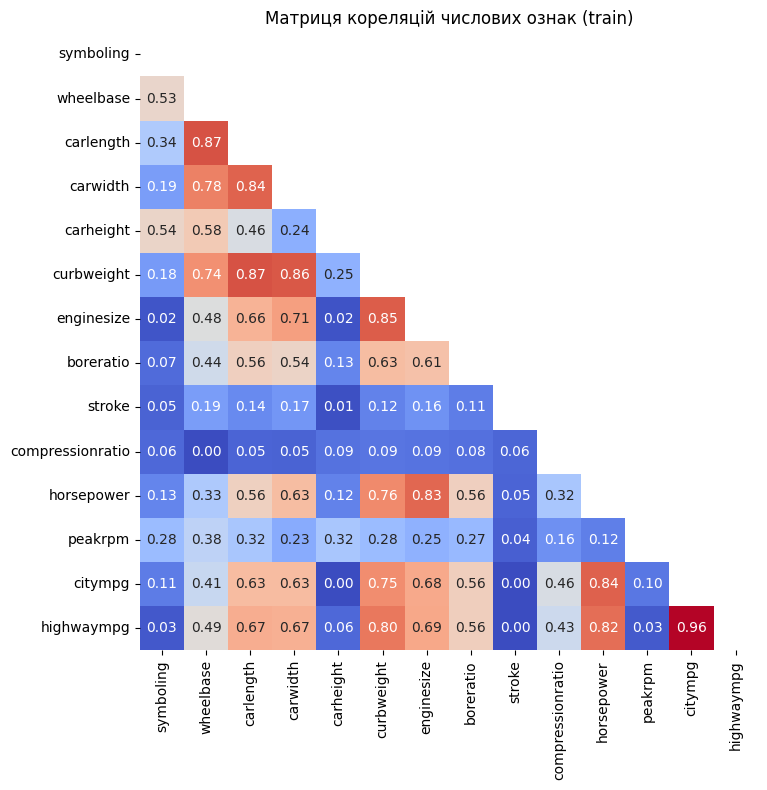

Сильно корельовані пари (|r| > 0.85):
wheelbase - carlength: 0.867
carlength - curbweight: 0.866
carwidth - curbweight: 0.858
citympg - highwaympg: 0.964
Ознаки для видалення: ['carlength', 'carwidth', 'citympg', 'wheelbase']


In [13]:
# Ваш код:
numeric_train_cols = X_train.select_dtypes(include=np.number).columns

corr = X_train[numeric_train_cols].corr().abs()

plt.figure(figsize=(10, 8))

sns.heatmap(
    corr,
    cmap="coolwarm",
    annot=True,
    fmt=".2f",
    mask=np.triu(np.ones_like(corr, dtype=bool)),
    square=True,
    cbar=False,
)

plt.title("Матриця кореляцій числових ознак (train)")
plt.tight_layout()
plt.show()

target_corr = pd.concat(
    [
        X_train[numeric_train_cols],
        y_train.rename("price")
    ],
    axis=1
).corr(numeric_only=True)["price"].abs()

upper = corr.where(
    np.triu(np.ones(corr.shape), k=1).astype(bool)
)

pairs = []

for col in upper.columns:
  for row in upper.index[upper[col] > 0.85]:
    pairs.append(
        (row, col, upper.loc[row, col])
    )

features_to_drop = set()

for a, b, r in pairs:
  if target_corr[a] < target_corr[b]:
    features_to_drop.add(a)
  else:
    features_to_drop.add(b)

print("Сильно корельовані пари (|r| > 0.85):")
for a, b, r in pairs:
  print(f"{a} - {b}: {r:.3f}")

print("Ознаки для видалення:", sorted(features_to_drop))
X_train = X_train.drop(
    columns=list(features_to_drop)
)

X_test = X_test.drop(
    columns=list(features_to_drop)
)

### Завдання 8. Передобробка: зменшення асиметрії та кодування категорій

In [15]:
# Ваш код:
continuous_cols = [
    c for c in X_train.select_dtypes(include=np.number).columns
    if c != "symboling"
]

ordinal_numeric_cols = [
    c for c in X_train.select_dtypes(include=np.number).columns
    if c == "symboling"
]

categorical_cols = (
    X_train
    .select_dtypes(exclude=np.number)
    .columns
    .tolist()
)

numeric_pipeline = Pipeline(steps=[
("power", PowerTransformer(
    method="yeo-johnson",
    standardize=False
 )),

 ("scaler", StandardScaler()),
])

ordinal_pipeline = Pipeline(steps=[
    ("scaler", StandardScaler()),
])

categorical_pipeline = Pipeline(steps=[
    ("onehot", OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=False
    )),
])

preprocessor = ColumnTransformer(
    transformers=[
        ("continuous", numeric_pipeline, continuous_cols),
        ("ordinal", ordinal_pipeline, ordinal_numeric_cols),
        ("categorical", categorical_pipeline, categorical_cols),
    ],

    remainder="drop",

    verbose_feature_names_out=False,
)
num_check = clone(numeric_pipeline)
num_train_transformed = pd.DataFrame(
    num_check.fit_transform(
        X_train[continuous_cols]
    ),
    columns=continuous_cols,
    index=X_train.index,
)
skewness_after = (
    num_train_transformed
    .skew()
    .sort_values(
        key=np.abs,
        ascending=False
    )
)
display(
    skewness_after.to_frame("skewness_after")
)

,skewness_after
horsepower,0.066280
curbweight,0.049894
enginesize,0.044834
stroke,0.015846
highwaympg,-0.012188
boreratio,-0.005941
carheight,-0.005170
compressionratio,0.004872
peakrpm,-0.003589


### Завдання 9. Побудова регресійних моделей

In [16]:
# Ваш код:
estimators = {
    "Linear Regression": LinearRegression(),
    "Ridge": Ridge(
        alpha=1.0
    ),
    "Lasso": Lasso(
        alpha=1.0,
        max_iter=20000
    ),
    "Random Forest": RandomForestRegressor(
        n_estimators=500,
        random_state=42,
        n_jobs=-1
    ),
    "Gradient Boosting": GradientBoostingRegressor(
        random_state=42
    ),
    "SVR": SVR(),
}

models = {
    name: Pipeline(steps=[
        ("preprocess", clone(preprocessor)),
        ("model", estimator),
    ])
    for name, estimator in estimators.items()
}

### Завдання 10.

In [17]:
# Ваш код:
results = []
predictions = {}
for name, model in models.items():
  model.fit(X_train, y_train)
  y_pred = model.predict(X_test)
  predictions[name] = y_pred
  results.append({
      "Model": name,
      "R²": r2_score(
          y_test,
          y_pred
      ),
      "MAE": mean_absolute_error(
          y_test,
          y_pred
      ),
      "MSE": mean_squared_error(
          y_test,
          y_pred
      ),
      "MAPE, %": mean_absolute_percentage_error(
          y_test,
          y_pred
      ) * 100,
  })

  results_df = (
      pd.DataFrame(results)
      .sort_values(
         "R²",
         ascending=False
      )
  )

  display(results_df)

,Model,R²,MAE,MSE,"MAPE, %"
0,Linear Regression,0.879431,2156.098245,9.518236e+06,16.376447


,Model,R²,MAE,MSE,"MAPE, %"
0,Linear Regression,0.879431,2156.098245,9.518236e+06,16.376447
1,Ridge,0.853789,2367.223583,1.154249e+07,18.193087


,Model,R²,MAE,MSE,"MAPE, %"
0,Linear Regression,0.879431,2156.098245,9.518236e+06,16.376447
2,Lasso,0.878234,2105.214295,9.612671e+06,15.133568
1,Ridge,0.853789,2367.223583,1.154249e+07,18.193087


,Model,R²,MAE,MSE,"MAPE, %"
3,Random Forest,0.954906,1318.781760,3.559886e+06,9.695253
0,Linear Regression,0.879431,2156.098245,9.518236e+06,16.376447
2,Lasso,0.878234,2105.214295,9.612671e+06,15.133568
1,Ridge,0.853789,2367.223583,1.154249e+07,18.193087


,Model,R²,MAE,MSE,"MAPE, %"
3,Random Forest,0.954906,1318.781760,3.559886e+06,9.695253
4,Gradient Boosting,0.930420,1727.403684,5.492942e+06,12.050186
0,Linear Regression,0.879431,2156.098245,9.518236e+06,16.376447
2,Lasso,0.878234,2105.214295,9.612671e+06,15.133568
1,Ridge,0.853789,2367.223583,1.154249e+07,18.193087


,Model,R²,MAE,MSE,"MAPE, %"
3,Random Forest,0.954906,1318.781760,3.559886e+06,9.695253
4,Gradient Boosting,0.930420,1727.403684,5.492942e+06,12.050186
0,Linear Regression,0.879431,2156.098245,9.518236e+06,16.376447
2,Lasso,0.878234,2105.214295,9.612671e+06,15.133568
1,Ridge,0.853789,2367.223583,1.154249e+07,18.193087
5,SVR,-0.099732,5696.776966,8.681724e+07,36.027666


### Завдання 11. Фактичні та прогнозовані значення

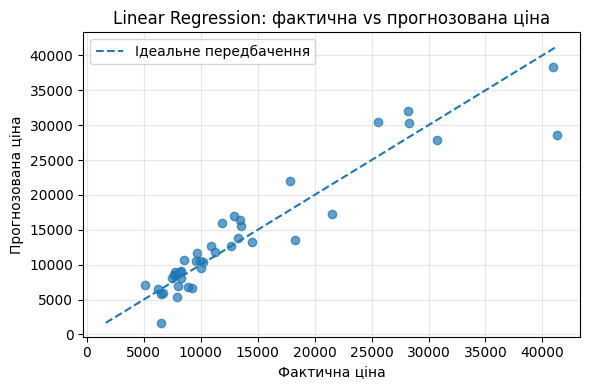

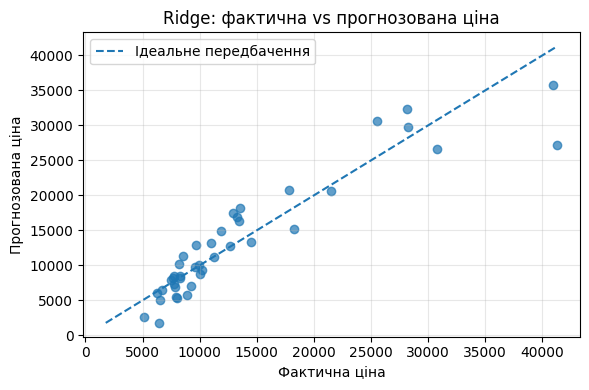

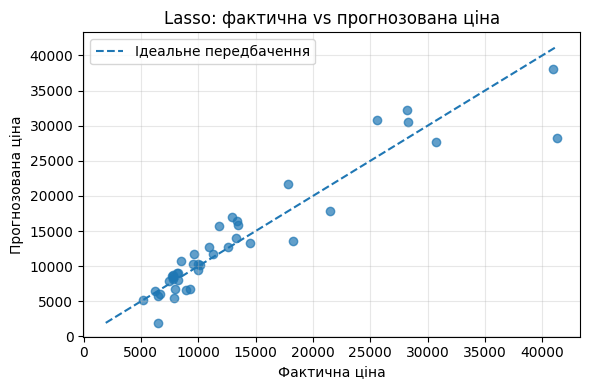

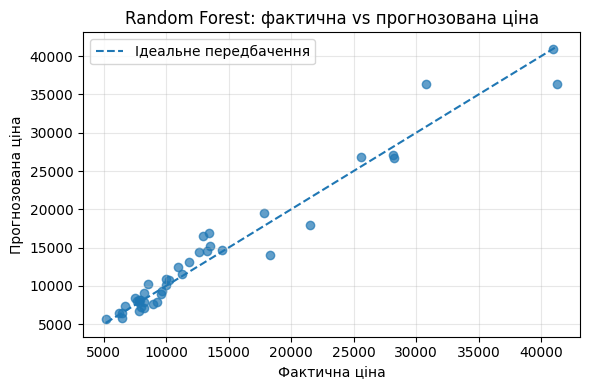

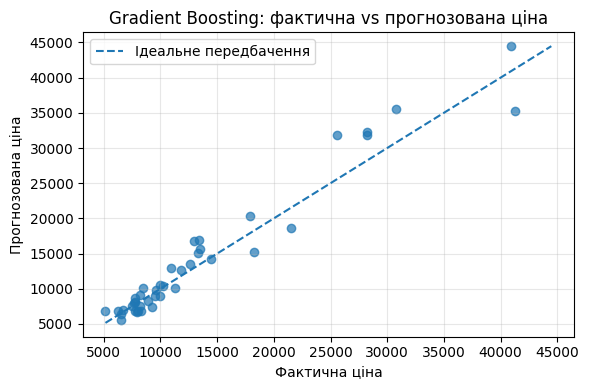

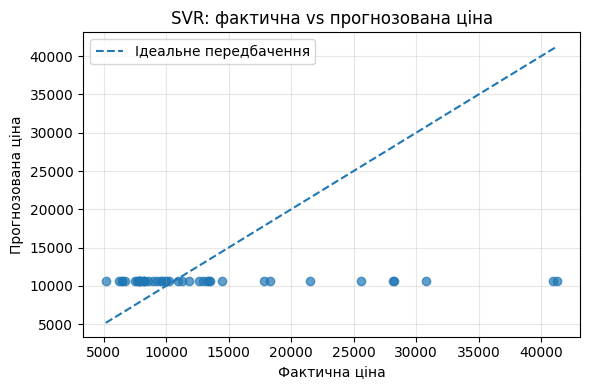

In [18]:
# Ваш код:
y_true = y_test.to_numpy()

for name, y_pred in predictions.items():
  y_pred = np.asarray(y_pred).ravel()
  lo = min(y_true.min(), y_pred.min())
  hi = max(y_true.max(), y_pred.max())

  plt.figure(figsize=(6, 4))
  plt.scatter(y_true, y_pred, alpha=0.7)
  plt.plot([lo, hi], [lo, hi], "--", label="Ідеальне передбачення")
  plt.xlabel("Фактична ціна")
  plt.ylabel("Прогнозована ціна")
  plt.title(f"{name}: фактична vs прогнозована ціна")
  plt.legend()
  plt.grid(alpha=0.3)
  plt.tight_layout()
  plt.show()